<a href="https://colab.research.google.com/github/Kari-2005/carisurg-portfolio/blob/main/notebooks/Week5_Interim_Data_Exploration_Ansarah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Ansarah Mohammed - Week 5 Interim

In [1]:
# Mounting the google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
# Path to the dataset in Google Drive
file_path = "/content/drive/MyDrive/CARISURG/Week5/yaleemmlc_admissionprediction_triage.csv"

# Folder where plots and outputs will be saved
output_folder = "/content/drive/MyDrive/CARISURG/Week5/docs"
os.makedirs(output_folder, exist_ok=True)

print("Dataset path:", file_path)
print("Output folder:", output_folder)

Dataset path: /content/drive/MyDrive/CARISURG/Week5/yaleemmlc_admissionprediction_triage.csv
Output folder: /content/drive/MyDrive/CARISURG/Week5/docs


In [4]:
# Loading the dataset
df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset shape: (55121, 226)


,Unnamed: 0,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
## Basic Dataset Overview
## This section checks the structure of the dataset, including the number of
## emergency department encounters, number of columns, column names
## and data types.

# Number of rows and columns
num_rows, num_cols = df.shape

print("Number of ED encounters:", num_rows)
print("Number of columns:", num_cols)

# Display column names
df.columns.tolist()

Number of ED encounters: 55121
Number of columns: 226


['Unnamed: 0',
 'dep_name',
 'esi',
 'age',
 'gender',
 'ethnicity',
 'race',
 'lang',
 'religion',
 'maritalstatus',
 'employstatus',
 'insurance_status',
 'disposition',
 'arrivalmode',
 'arrivalmonth',
 'arrivalday',
 'arrivalhour_bin',
 'previousdispo',
 'triage_vital_hr',
 'triage_vital_sbp',
 'triage_vital_dbp',
 'triage_vital_rr',
 'triage_vital_o2',
 'triage_vital_o2_device',
 'triage_vital_temp',
 'triage_glucose',
 'cc_abdominalcramping',
 'cc_abdominaldistention',
 'cc_abdominalpain',
 'cc_abdominalpainpregnant',
 'cc_abnormallab',
 'cc_abscess',
 'cc_addictionproblem',
 'cc_agitation',
 'cc_alcoholintoxication',
 'cc_alcoholproblem',
 'cc_allergicreaction',
 'cc_alteredmentalstatus',
 'cc_animalbite',
 'cc_ankleinjury',
 'cc_anklepain',
 'cc_anxiety',
 'cc_arminjury',
 'cc_armpain',
 'cc_armswelling',
 'cc_assaultvictim',
 'cc_asthma',
 'cc_backpain',
 'cc_bleeding/bruising',
 'cc_blurredvision',
 'cc_bodyfluidexposure',
 'cc_breastpain',
 'cc_breathingdifficulty',
 'cc_bre

In [6]:
## Data Type Check
## Here I checked the data types to identify whether the dataset contains
## numerical, categorical, or mixed variables. This helps decide which columns
## may need cleaning or encoding before modelling in Week 6.

# Data type summary
dtype_summary = df.dtypes.value_counts()

print("Data type summary:")
print(dtype_summary)

# Full column data type table
data_types = pd.DataFrame({
    "column": df.columns,
    "data_type": df.dtypes.astype(str).values
})

data_types.head(30)

Data type summary:
float64    210
object      15
int64        1
Name: count, dtype: int64


,column,data_type
0,Unnamed: 0,int64
1,dep_name,object
2,esi,float64
3,age,float64
4,gender,object
5,ethnicity,object
6,race,object
7,lang,object
8,religion,object
9,maritalstatus,object


In [7]:
## Missing Values Summary
## Here every column was checked for missing values. This is important because
## missing clinical data can affect whether the dataset is suitable for building
## a triage model.

missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().sum() / len(df)) * 100
}).sort_values("missing_percent", ascending=False)

missing_summary.head(25)

,missing_count,missing_percent
Unnamed: 0,0,0.0
dep_name,0,0.0
esi,0,0.0
age,0,0.0
gender,0,0.0
ethnicity,0,0.0
race,0,0.0
lang,0,0.0
religion,0,0.0
maritalstatus,0,0.0


In [8]:
## Missingness Table
## The missingness summary was saved as a CSV file so it can be included in the
## Week 5 documentation folder.

missing_table_path = os.path.join(output_folder, "week5_missingness_table.csv")

missing_summary.to_csv(missing_table_path)

print("Missingness table saved to:")
print(missing_table_path)

Missingness table saved to:
/content/drive/MyDrive/CARISURG/Week5/docs/week5_missingness_table.csv


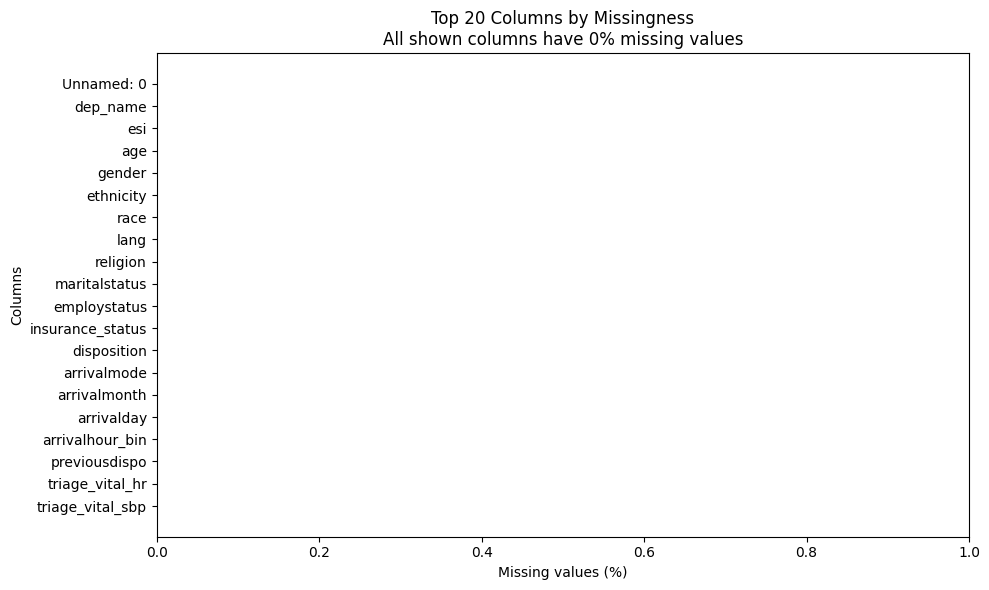

Missingness plot saved to:
/content/drive/MyDrive/CARISURG/Week5/docs/week5_missingness_plot.png


In [10]:
## Missingness Visualisation
## A missingness plot was created for the Week 5 interim submission. This visual
## helps show whether any columns have missing values that may affect modelling.

# Select top 20 columns by missing percentage
top_missing = missing_summary.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top_missing.index, top_missing["missing_percent"])

plt.xlabel("Missing values (%)")
plt.ylabel("Columns")
plt.title("Top 20 Columns by Missingness\nAll shown columns have 0% missing values")

# Make the zero values easier to interpret
plt.xlim(0, 1)

plt.gca().invert_yaxis()
plt.tight_layout()

missing_plot_path = os.path.join(output_folder, "week5_missingness_plot.png")
plt.savefig(missing_plot_path, dpi=300, bbox_inches="tight")

plt.show()

print("Missingness plot saved to:")
print(missing_plot_path)

In [ ]:
## Missingness Plot Interpretation
## The missingness plot shows that the top 20 columns all have 0% missing values.
## This suggests that the dataset is complete from a missing-value perspective.
## However, this does not mean the dataset is automatically ready for modelling,
## because other quality issues still need to be checked, including class
## imbalance, possible outliers, inconsistent values, and leakage columns such
## as `disposition` and `previousdispo`.

In [11]:
## Target Variable: ESI Triage Level
## The target variable for triage modelling is `esi`, which represents the
## Emergency Severity Index level. ESI level 1 is the most urgent, while ESI
## level 5 is the least urgent.

esi_counts = df["esi"].value_counts().sort_index()
esi_percent = (esi_counts / len(df)) * 100

esi_summary = pd.DataFrame({
    "count": esi_counts,
    "percent": esi_percent.round(2)
})

esi_summary

,count,percent
esi,,
1.0,77,0.14
2.0,17924,32.52
3.0,27010,49.00
4.0,8896,16.14
5.0,1214,2.20


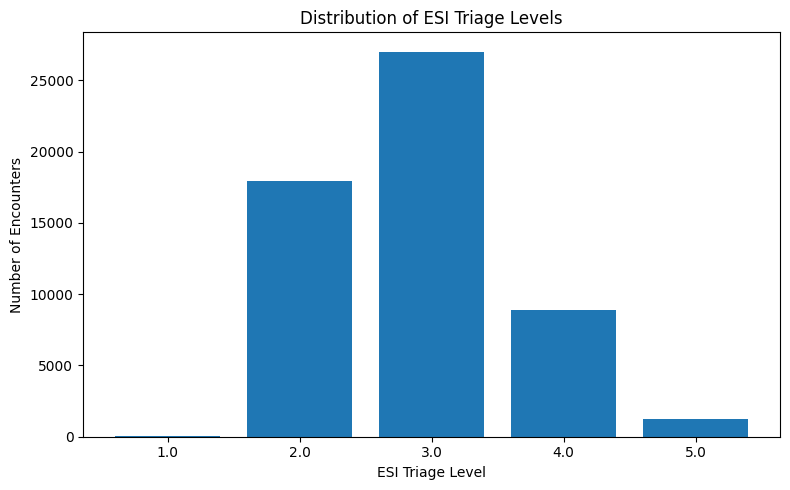

ESI distribution plot saved to:
/content/drive/MyDrive/CARISURG/Week5/docs/week5_esi_distribution.png


In [12]:
## ESI Class Distribution
## I plotted the distribution of ESI triage levels to check whether the dataset
## is balanced across urgency categories. This is important because very rare
## classes may be harder for a model to learn.

plt.figure(figsize=(8, 5))
plt.bar(esi_summary.index.astype(str), esi_summary["count"])
plt.xlabel("ESI Triage Level")
plt.ylabel("Number of Encounters")
plt.title("Distribution of ESI Triage Levels")
plt.tight_layout()

esi_plot_path = os.path.join(output_folder, "week5_esi_distribution.png")
plt.savefig(esi_plot_path, dpi=300, bbox_inches="tight")

plt.show()

print("ESI distribution plot saved to:")
print(esi_plot_path)

In [13]:
## Demographic Variables
## I reviewed selected demographic variables such as age, gender, race and
## ethnicity. These variables help describe the patient population and may also
## raise questions about representativeness and fairness.

demographic_cols = ["age", "gender", "race", "ethnicity"]

for col in demographic_cols:
    if col in df.columns:
        print("\nColumn:", col)
        print(df[col].value_counts(dropna=False).head(10))


Column: age
age
53.0    1285
54.0    1278
52.0    1196
55.0    1185
57.0    1156
59.0    1139
51.0    1131
56.0    1126
58.0    1109
50.0    1100
Name: count, dtype: int64

Column: gender
gender
Female    31744
Male      23377
Name: count, dtype: int64

Column: race
race
White or Caucasian                           29435
Black or African American                    15963
Other                                         9016
Patient Refused                                370
Asian                                          175
Unknown                                         76
American Indian or Alaska Native                66
Native Hawaiian or Other Pacific Islander       20
Name: count, dtype: int64

Column: ethnicity
ethnicity
Non-Hispanic          45142
Hispanic or Latino     9888
Patient Refused          56
Unknown                  35
Name: count, dtype: int64


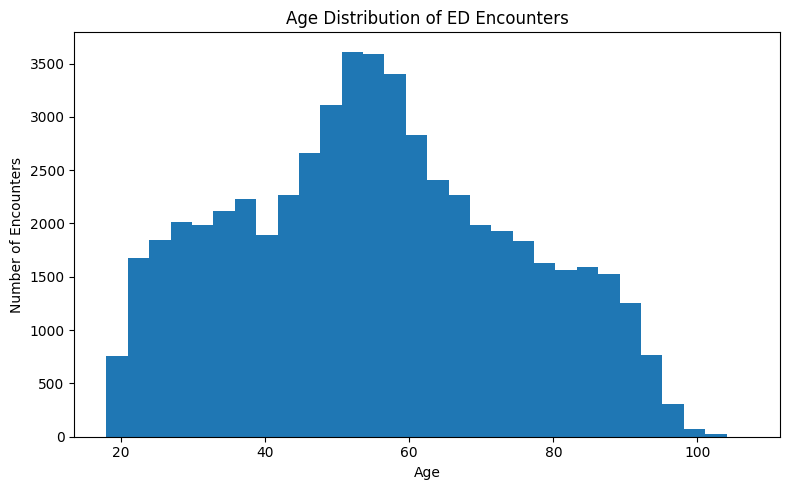

Age distribution plot saved to:
/content/drive/MyDrive/CARISURG/Week5/docs/week5_age_distribution.png


In [14]:
## Age Distribution
## Age is clinically relevant in emergency triage because older and younger
## patients may have different risk profiles. I plotted the age distribution to
## understand the patient population.

plt.figure(figsize=(8, 5))
plt.hist(df["age"], bins=30)
plt.xlabel("Age")
plt.ylabel("Number of Encounters")
plt.title("Age Distribution of ED Encounters")
plt.tight_layout()

age_plot_path = os.path.join(output_folder, "week5_age_distribution.png")
plt.savefig(age_plot_path, dpi=300, bbox_inches="tight")

plt.show()

print("Age distribution plot saved to:")
print(age_plot_path)

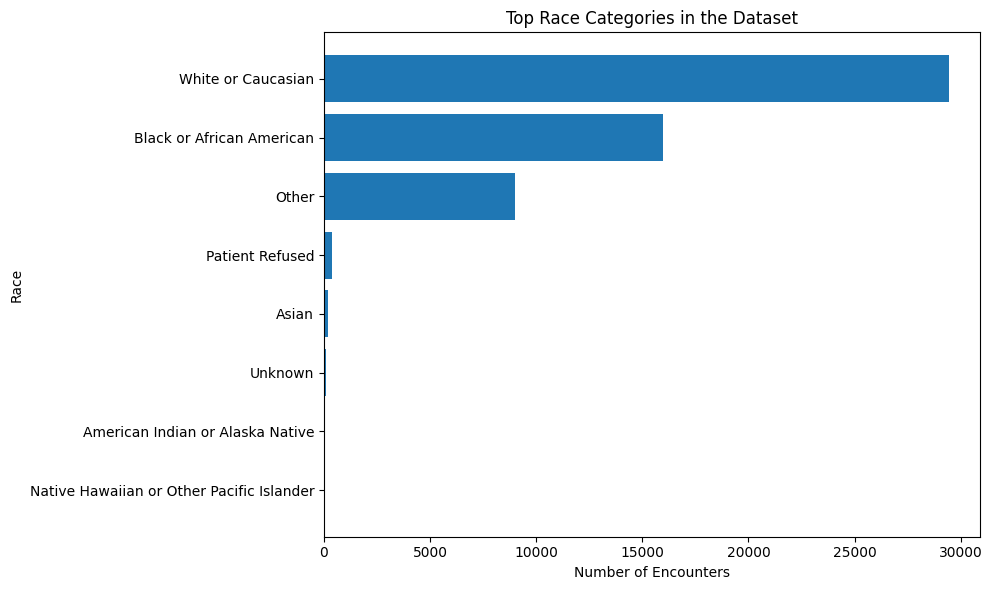

Race distribution plot saved to:
/content/drive/MyDrive/CARISURG/Week5/docs/week5_race_distribution.png


In [15]:
## Race Distribution
## Race distribution was reviewed because the Week 5 task asks for exploration
## of race and ethnicity. This also helps identify whether the dataset may
## represent some groups more than others.

if "race" in df.columns:
    race_counts = df["race"].value_counts().head(10)

    plt.figure(figsize=(10, 6))
    plt.barh(race_counts.index.astype(str), race_counts.values)
    plt.xlabel("Number of Encounters")
    plt.ylabel("Race")
    plt.title("Top Race Categories in the Dataset")
    plt.gca().invert_yaxis()
    plt.tight_layout()

    race_plot_path = os.path.join(output_folder, "week5_race_distribution.png")
    plt.savefig(race_plot_path, dpi=300, bbox_inches="tight")

    plt.show()

    print("Race distribution plot saved to:")
    print(race_plot_path)
else:
    print("Race column not found.")

In [16]:
## Chief Complaint Features
## The dataset contains many chief complaint flag columns beginning with `cc_`.
## These represent symptoms or reasons for visiting the emergency department.
## I counted these columns and identified the most common complaints.

cc_cols = [col for col in df.columns if col.startswith("cc_")]

print("Number of chief complaint columns:", len(cc_cols))

# Count how often each chief complaint appears
cc_counts = df[cc_cols].sum().sort_values(ascending=False)

cc_counts.head(15)

Number of chief complaint columns: 200


,0
cc_abdominalpain,6717.0
cc_other,4491.0
cc_chestpain,3712.0
cc_shortnessofbreath,3098.0
cc_backpain,1997.0
cc_fall,1926.0
cc_cough,1439.0
cc_dizziness,1292.0
cc_legpain,1264.0
cc_emesis,1249.0


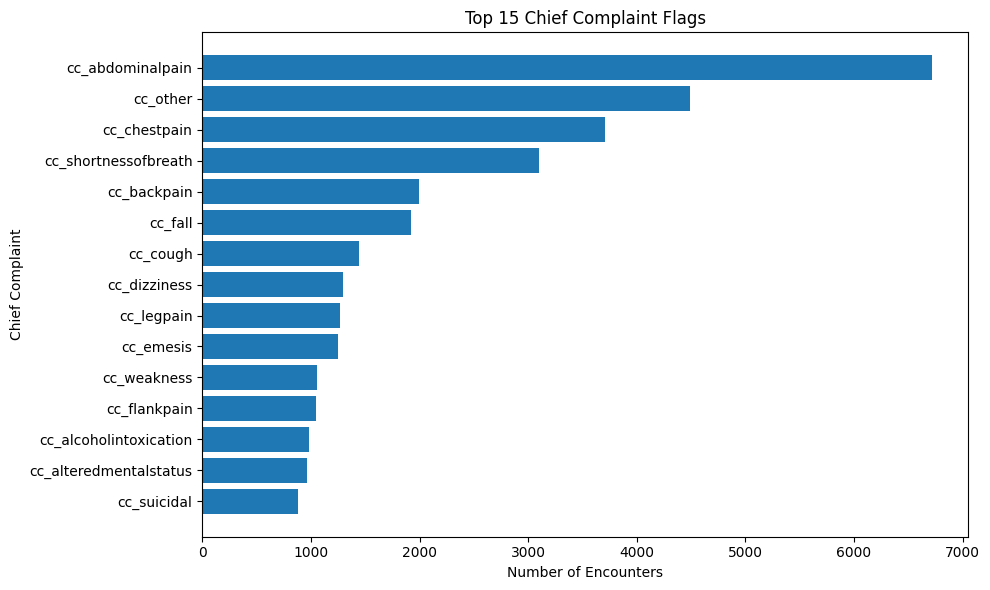

Chief complaint plot saved to:
/content/drive/MyDrive/CARISURG/Week5/docs/week5_top_chief_complaints.png


In [17]:
## Most Common Chief Complaints
## I plotted the most common chief complaints to understand the types of
## cases represented in the dataset.

top_cc = cc_counts.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_cc.index, top_cc.values)
plt.xlabel("Number of Encounters")
plt.ylabel("Chief Complaint")
plt.title("Top 15 Chief Complaint Flags")
plt.gca().invert_yaxis()
plt.tight_layout()

cc_plot_path = os.path.join(output_folder, "week5_top_chief_complaints.png")
plt.savefig(cc_plot_path, dpi=300, bbox_inches="tight")

plt.show()

print("Chief complaint plot saved to:")
print(cc_plot_path)

In [18]:
## Initial Feature Shortlist
## Based on clinical intuition and initial exploration, I created an early
## shortlist of features that may be useful for predicting ESI triage level.
## This is not a final model result. It is a Week 5 hypothesis to test in Week 6.

feature_shortlist = pd.DataFrame({
    "rank": list(range(1, 11)),
    "feature": [
        "age",
        "triage_vital_o2",
        "triage_vital_o2_device",
        "triage_vital_hr",
        "triage_vital_rr",
        "triage_vital_sbp",
        "triage_vital_dbp",
        "triage_vital_temp",
        "triage_glucose",
        "selected cc_ chief complaint flags"
    ],
    "reasoning": [
        "Age is clinically relevant because risk and triage priority can vary across age groups.",
        "Oxygen saturation reflects respiratory status and can signal urgent deterioration.",
        "Use of an oxygen device may indicate higher clinical concern at triage.",
        "Heart rate can reflect pain, fever, shock, anxiety, or acute illness.",
        "Respiratory rate is a key vital sign for identifying respiratory distress.",
        "Systolic blood pressure can indicate hypotension, shock, or severe hypertension.",
        "Diastolic blood pressure adds context to overall blood pressure status.",
        "Temperature can indicate infection, fever, or other acute illness.",
        "Glucose is important for identifying acute metabolic problems.",
        "Chief complaint flags capture the reason for attendance and may identify red-flag presentations."
    ]
})

feature_shortlist

,rank,feature,reasoning
0,1,age,Age is clinically relevant because risk and tr...
1,2,triage_vital_o2,Oxygen saturation reflects respiratory status ...
2,3,triage_vital_o2_device,Use of an oxygen device may indicate higher cl...
3,4,triage_vital_hr,"Heart rate can reflect pain, fever, shock, anx..."
4,5,triage_vital_rr,Respiratory rate is a key vital sign for ident...
5,6,triage_vital_sbp,Systolic blood pressure can indicate hypotensi...
6,7,triage_vital_dbp,Diastolic blood pressure adds context to overa...
7,8,triage_vital_temp,"Temperature can indicate infection, fever, or ..."
8,9,triage_glucose,Glucose is important for identifying acute met...
9,10,selected cc_ chief complaint flags,Chief complaint flags capture the reason for a...


In [19]:
## Save Feature Shortlist
## The initial top-10 feature shortlist was saved for use in the feasibility
## memo outline and Week 6 baseline modelling.

shortlist_path = os.path.join(output_folder, "week5_initial_feature_shortlist.csv")

feature_shortlist.to_csv(shortlist_path, index=False)

print("Feature shortlist saved to:")
print(shortlist_path)

Feature shortlist saved to:
/content/drive/MyDrive/CARISURG/Week5/docs/week5_initial_feature_shortlist.csv


In [20]:
## Feasibility Memo Outline
## For the interim submission, I created an outline of the Week 5 feasibility
## memo. The final memo will be written for a clinical audience and will include
## a clear verdict, dataset summary, main concerns, reasons to proceed, caveats
## and the feature shortlist.


memo_outline = """
# Week 5 Feasibility Memo Outline

## One-Sentence Verdict
This dataset is suitable for building a baseline triage model, provided leakage columns are excluded, rare ESI classes are handled carefully, and results are treated as exploratory until validated in a Caribbean emergency department setting.

## Dataset Summary
The dataset contains 55,121 emergency department encounters and 226 columns. These include patient demographics, triage vital signs, arrival details, disposition-related variables, and chief complaint flags. The main target variable is `esi`, which represents Emergency Severity Index triage level.

## Top 3 Quality Concerns

1. **Class imbalance**
   ESI level 1 cases are very rare compared with ESI levels 2, 3, and 4. This may make it harder for a model to learn the sickest patient group.

2. **Outcome leakage**
   Columns such as `disposition` and `previousdispo` may contain information known after triage. These should be excluded from Week 6 modelling because a real triage model would not have access to them at the time of decision-making.

3. **External validity**
   The dataset may not fully represent a Caribbean emergency department population, workflow, staffing pattern, or resource setting. Any model built from it would need local validation before clinical use.

## Top 3 Reasons to Proceed

1. **Real triage target**
   The dataset includes the `esi` triage label, so it can support baseline supervised modelling.

2. **Clinically relevant triage features**
   The dataset includes important vital signs such as heart rate, blood pressure, respiratory rate, oxygen saturation, temperature, and glucose.

3. **Rich chief complaint information**
   The dataset contains many chief complaint flags, which may help capture why patients attended the emergency department.

## Caveats

This Week 5 analysis does not build a model yet. The visualisations and summaries only show early data quality patterns. Correlation or association should not be treated as proof of prediction. Week 6 should test baseline models while excluding leakage columns and documenting all preprocessing decisions.

## Initial Top-10 Feature Shortlist

1. age
2. triage_vital_o2
3. triage_vital_o2_device
4. triage_vital_hr
5. triage_vital_rr
6. triage_vital_sbp
7. triage_vital_dbp
8. triage_vital_temp
9. triage_glucose
10. selected chief complaint flags
"""

memo_path = os.path.join(output_folder, "week5_feasibility_memo_outline.md")

with open(memo_path, "w") as file:
    file.write(memo_outline)

print("Memo outline saved to:")
print(memo_path)

Memo outline saved to:
/content/drive/MyDrive/CARISURG/Week5/docs/week5_feasibility_memo_outline.md


In [21]:
## Interim Output Check
## This section confirms that the main Week 5 interim files were created:
## the missingness table, missingness plot, ESI distribution plot, feature
## shortlist, and feasibility memo outline.

saved_files = os.listdir(output_folder)

print("Files saved in docs folder:")
for file in saved_files:
    print("-", file)

Files saved in docs folder:
- week5_missingness_table.csv
- week5_missingness_plot.png
- week5_esi_distribution.png
- week5_age_distribution.png
- week5_race_distribution.png
- week5_top_chief_complaints.png
- week5_initial_feature_shortlist.csv
- week5_feasibility_memo_outline.md
